In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.metrics import accuracy_score
import cv2
import os
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , VotingClassifier
import warnings

In [2]:
pth = os.listdir('../MRI_DATASET/Training/')
classes = {'notumor':0, 'pituitary':1, 'meningioma':2 , 'glioma':3}

In [3]:
pth = '../MRI_DATASET/Training/'  

In [4]:
X = []
Y = []

for cls in classes:
    class_path = os.path.join(pth, cls)
    for j in os.listdir(class_path):
        img_path = os.path.join(class_path, j)
        
        # Check if the file is an image by its extension
        if not j.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            print(f"Skipping non-image file: {img_path}")
            continue
        
        img = cv2.imread(img_path, 0)
        
        if img is not None:
            try:
                img = cv2.resize(img, (256, 256))
                
                # Verify the shape of the image
                if img.shape != (256, 256):
                    print(f"Skipping image with incorrect shape: {img_path}, shape: {img.shape}")
                    continue
                
                X.append(img)
                Y.append(classes[cls])
            except Exception as e:
                print(f"Error resizing image {img_path}: {e}")
        else:
            print(f"Warning: Could not load image {img_path}")

# Debugging: Check for any elements with incorrect shape in X
for idx, img in enumerate(X):
    if img.shape != (256, 256):
        print(f"Incorrect shape found at index {idx}: {img.shape}")

# Convert lists to numpy arrays
try:
    X = np.array(X)
    Y = np.array(Y)
    print(f"Successfully converted to numpy arrays. Shape of X: {X.shape}, Shape of Y: {Y.shape}")
except ValueError as ve:
    print(f"Error converting to numpy arrays: {ve}")

# Flatten the images if necessary
if isinstance(X, np.ndarray) and len(X) > 0:
    X_updated = X.reshape(len(X), -1)
    print(f"Shape of X_updated: {X_updated.shape}")
else:
    print("X is not a numpy array or is empty.")

Skipping non-image file: ../MRI_DATASET/Training/pituitary\.ipynb_checkpoints
Successfully converted to numpy arrays. Shape of X: (6984, 256, 256), Shape of Y: (6984,)
Shape of X_updated: (6984, 65536)


In [5]:
X.shape

(6984, 256, 256)

In [6]:
xtrain, xtest, ytrain, ytest = train_test_split(X_updated,Y,random_state=10,test_size=0.20)

In [7]:
xtrain.shape

(5587, 65536)

In [8]:
xtest.shape

(1397, 65536)

### Feature scaling

In [9]:
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())
xtrain = xtrain/255
xtest = xtest/255
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())

255 0
255 0
1.0 0.0
1.0 0.0


### Feaure Selection: PCA

In [10]:
## if we use pca we might loss important fetures so in this case im not going to use pca

In [11]:
print(xtrain.shape, xtest.shape)

pca = PCA(.98)
# pca_train = pca.fit_transform(xtrain)
# pca_test = pca.transform(xtest)
pca_train = xtrain
pca_test = xtest

(5587, 65536) (1397, 65536)


In [12]:
# print(pca_train.shape, pca_test.shape)
# print(pca.n_components_)
# print(pca.n_features_)

### MODEL TRAINING

#### LOGISTIC REGRESSION MODEL

In [13]:

warnings.filterwarnings('ignore')

lg = LogisticRegression(C=0.1)
lg.fit(xtrain, ytrain)


LogisticRegression(C=0.1)

In [14]:
print("Training Score:", lg.score(xtrain, ytrain))
print("Testing Score:", lg.score(xtest, ytest))

Training Score: 0.9801324503311258
Testing Score: 0.8389405869720831


### Classification Report For LOGISTIC REGRESSION

In [15]:
# Make predictions on the test set
y_pred_lg = lg.predict(xtest)

In [16]:
# Evaluate the model
accuracy_lg = accuracy_score(ytest, y_pred_lg)
print(f'Logistic Model Accuracy: {accuracy_lg:.2f}')

Logistic Model Accuracy: 0.84


In [17]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(ytest, y_pred_lg)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[345   5  13   7]
 [  5 317  11  11]
 [ 20  24 241  58]
 [  4   8  59 269]]


In [18]:
# Generate the classification report
class_report = classification_report(ytest, y_pred_lg, target_names=classes.keys())
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

     notumor       0.92      0.93      0.93       370
   pituitary       0.90      0.92      0.91       344
  meningioma       0.74      0.70      0.72       343
      glioma       0.78      0.79      0.79       340

    accuracy                           0.84      1397
   macro avg       0.84      0.84      0.84      1397
weighted avg       0.84      0.84      0.84      1397



#### SVM MODEL

In [19]:
sv = SVC()
sv.fit(xtrain, ytrain)

SVC()

In [20]:
print("Training Score:", sv.score(xtrain, ytrain))
print("Testing Score:", sv.score(xtest, ytest))

Training Score: 0.9357436907105782
Testing Score: 0.882605583392985


In [21]:
# Make predictions on the test set
y_pred_sv = sv.predict(xtest)

In [22]:
# Evaluate the model
accuracy_sv = accuracy_score(ytest, y_pred_sv)
print(f'SVM Model Accuracy: {accuracy_sv:.2f}')

SVM Model Accuracy: 0.88


In [23]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(ytest, y_pred_sv)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[349   2   9  10]
 [  1 328   8   7]
 [ 15  21 258  49]
 [  4   9  29 298]]


### Classification Report For SVM

In [24]:
# Generate the classification report
class_report = classification_report(ytest, y_pred_sv, target_names=classes.keys())
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

     notumor       0.95      0.94      0.94       370
   pituitary       0.91      0.95      0.93       344
  meningioma       0.85      0.75      0.80       343
      glioma       0.82      0.88      0.85       340

    accuracy                           0.88      1397
   macro avg       0.88      0.88      0.88      1397
weighted avg       0.88      0.88      0.88      1397



#### DECISION TREE MODEL

In [25]:
dt = DecisionTreeClassifier()
dt.fit(xtrain, ytrain)

DecisionTreeClassifier()

In [26]:
print("Training Score:", dt.score(xtrain, ytrain))
print("Testing Score:", dt.score(xtest, ytest))

Training Score: 1.0
Testing Score: 0.800286327845383


In [27]:
# Make predictions on the test set
y_pred_dt = dt.predict(xtest)

In [28]:
# Evaluate the model
accuracy_dt = accuracy_score(ytest, y_pred_dt)
print(f'Decision tree Model Accuracy: {accuracy_dt:.2f}')

Decision tree Model Accuracy: 0.80


In [29]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(ytest, y_pred_dt)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[323  12  28   7]
 [ 11 275  41  17]
 [ 25  26 247  45]
 [ 16  16  35 273]]


### Classification Report For DT

In [30]:
# Generate the classification report
class_report = classification_report(ytest, y_pred_dt, target_names=classes.keys())
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

     notumor       0.86      0.87      0.87       370
   pituitary       0.84      0.80      0.82       344
  meningioma       0.70      0.72      0.71       343
      glioma       0.80      0.80      0.80       340

    accuracy                           0.80      1397
   macro avg       0.80      0.80      0.80      1397
weighted avg       0.80      0.80      0.80      1397



#### RANDOM FOREST MODEL

In [31]:
rf = DecisionTreeClassifier()
rf.fit(xtrain, ytrain)

DecisionTreeClassifier()

In [32]:
print("Training Score:", rf.score(xtrain, ytrain))
print("Testing Score:", rf.score(xtest, ytest))

Training Score: 1.0
Testing Score: 0.7952755905511811


In [33]:
# Make predictions on the test set
y_pred_rf = rf.predict(xtest)

In [34]:
# Evaluate the model
accuracy_rf = accuracy_score(ytest, y_pred_rf)
print(f'Random Forest Model Accuracy: {accuracy_rf:.2f}')

Random Forest Model Accuracy: 0.80


In [35]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(ytest, y_pred_rf)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[315  11  33  11]
 [  8 277  38  21]
 [ 27  29 243  44]
 [ 13  16  35 276]]


In [36]:
# Generate the classification report
class_report = classification_report(ytest, y_pred_rf, target_names=classes.keys())
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

     notumor       0.87      0.85      0.86       370
   pituitary       0.83      0.81      0.82       344
  meningioma       0.70      0.71      0.70       343
      glioma       0.78      0.81      0.80       340

    accuracy                           0.80      1397
   macro avg       0.79      0.79      0.79      1397
weighted avg       0.80      0.80      0.80      1397



### EMSEMBLE MODEL

In [37]:
# Create the ensemble model
ensemble_model = VotingClassifier(estimators=[
    ('dt', dt),
    ('rf', rf),
    ('sv', sv)
], voting='hard')  # 'soft' uses predicted probabilities, 'hard' uses predicted class labels

In [38]:
# Train the ensemble model
ensemble_model.fit(xtrain, ytrain)

VotingClassifier(estimators=[('dt', DecisionTreeClassifier()),
                             ('rf', DecisionTreeClassifier()), ('sv', SVC())])

In [39]:
# Predict on the test set
y_pred = ensemble_model.predict(xtest)

In [40]:
# Evaluate the model
accuracy_ens = accuracy_score(ytest, y_pred)
print(f'Ensemble Model Accuracy: {accuracy_ens:.2f}')

Ensemble Model Accuracy: 0.83


In [41]:
# Generate the classification report
class_report = classification_report(ytest, y_pred, target_names=classes.keys())
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

     notumor       0.86      0.91      0.88       370
   pituitary       0.85      0.85      0.85       344
  meningioma       0.76      0.75      0.75       343
      glioma       0.85      0.81      0.83       340

    accuracy                           0.83      1397
   macro avg       0.83      0.83      0.83      1397
weighted avg       0.83      0.83      0.83      1397



In [42]:
# Confusion matrix
conf_matrix = confusion_matrix(ytest, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

Confusion Matrix:
[[335   7  19   9]
 [ 13 292  33   6]
 [ 28  25 257  33]
 [ 13  20  30 277]]


In [43]:
# Precision, recall, and F1-score
precision = precision_score(ytest, y_pred, average='weighted')
recall = recall_score(ytest, y_pred, average='weighted')
f1 = f1_score(ytest, y_pred, average='weighted')

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')

Precision: 0.83
Recall: 0.83
F1-Score: 0.83


In [44]:
# Cross-validation
#cv_scores = cross_val_score(ensemble, X_updated, Y, cv=10)
#print(f'Cross-Validation Scores: {cv_scores}')
#print(f'Mean CV Score: {np.mean(cv_scores):.2f}')

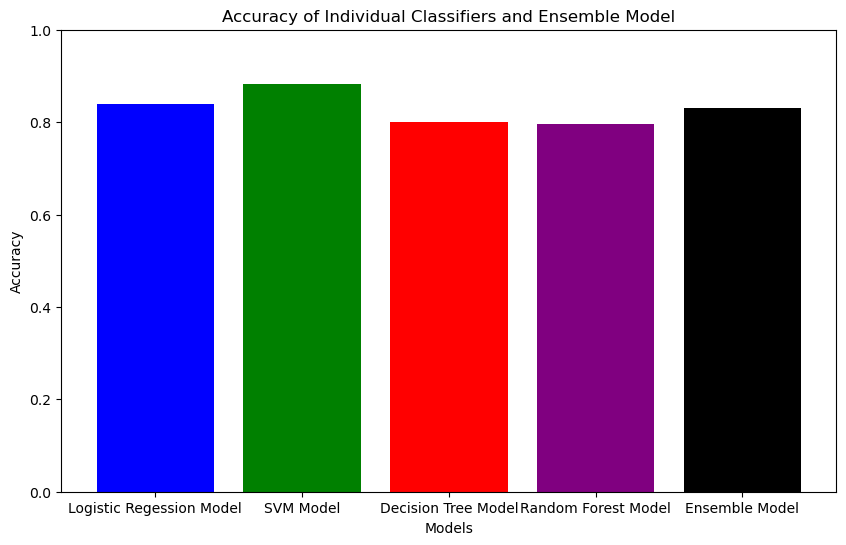

In [45]:
# Plot the accuracies
labels = ['Logistic Regession Model', 'SVM Model', 'Decision Tree Model', 'Random Forest Model' , 'Ensemble Model']
accuracies = [accuracy_lg, accuracy_sv, accuracy_dt, accuracy_rf , accuracy_ens]

plt.figure(figsize=(10, 6))
plt.bar(labels, accuracies, color=['blue', 'green', 'red', 'purple', 'black'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy of Individual Classifiers and Ensemble Model')
plt.ylim(0, 1)  # Assuming accuracy is a value between 0 and 1
plt.show()

In [46]:
import joblib

In [47]:
# Save the ensemble model
joblib.dump(ensemble_model, 'ensemble_model.pkl')

['ensemble_model.pkl']